First 5 Rows:
            Temp
Date            
1981-01-01  20.7
1981-01-02  17.9
1981-01-03  18.8
1981-01-04  14.6
1981-01-05  15.8

Missing Values:
Temp    0
dtype: int64

ADF Test Result
---------------------
ADF Statistic : -4.44052200655791
p-value       : 0.00025147236020337904
Data is Stationary


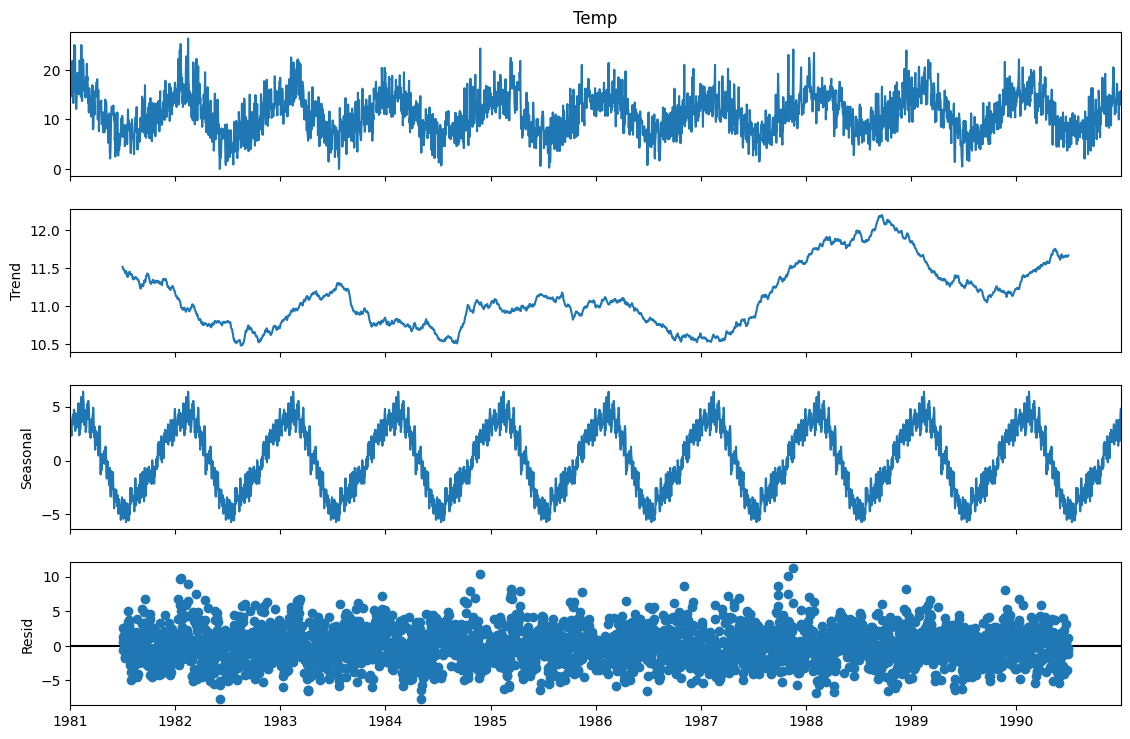

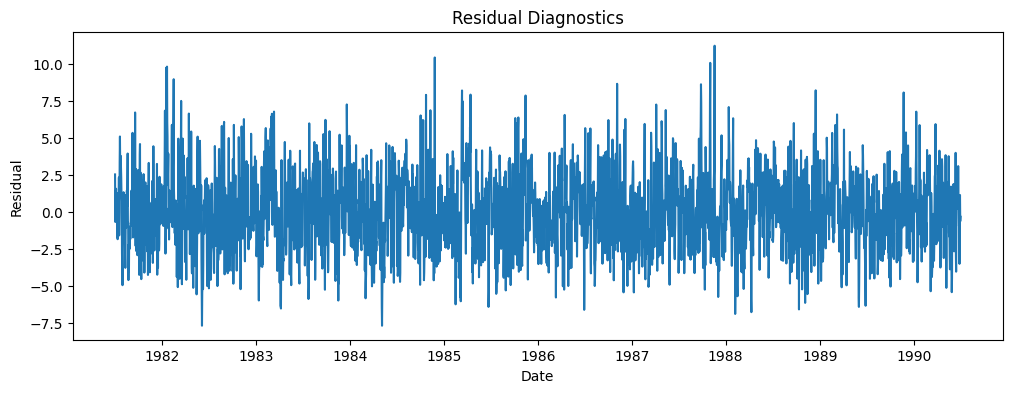


Practical Completed Successfully


In [2]:
# ==========================================
# PR_23 - Modular Analytical Workflow
# Using Real Temperature Dataset
# ==========================================

# ---------- Import Libraries ----------
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings('ignore')

# ---------- STEP 1: LOAD REAL DATASET ----------

# Load dataset
df = pd.read_csv(
    '1_Daily_minimum_temps.csv',
    parse_dates=['Date'],
    index_col='Date'
)

# Display first rows
print("First 5 Rows:")
print(df.head())

# ---------- STEP 2: HANDLE MISSING VALUES ----------

# 🔥 IMPORTANT FIX: Convert to numeric first (prevents interpolation error)
df['Temp'] = pd.to_numeric(df['Temp'], errors='coerce')

# Fill missing values using interpolation
df['Temp'] = df['Temp'].interpolate(method='linear')

print("\nMissing Values:")
print(df.isnull().sum())

# ---------- STEP 3: STATIONARITY TEST ----------

adf_result = adfuller(df['Temp'].dropna())

print("\nADF Test Result")
print("---------------------")
print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])

# Interpretation
if adf_result[1] <= 0.05:
    print("Data is Stationary")
else:
    print("Data is Non-Stationary")

# ---------- STEP 4: TIME SERIES DECOMPOSITION ----------

# 365 because yearly seasonality in daily data
decomposition = seasonal_decompose(
    df['Temp'],
    model='additive',
    period=365
)

# Plot decomposition graphs
decomposition.plot()

# Increase graph size
plt.gcf().set_size_inches(12,8)

plt.show()

# ---------- STEP 5: RESIDUAL DIAGNOSTICS ----------

residual = decomposition.resid

plt.figure(figsize=(12,4))

plt.plot(residual)

plt.title("Residual Diagnostics")
plt.xlabel("Date")
plt.ylabel("Residual")

plt.show()

print("\nPractical Completed Successfully")